# Dimensionality reduction for visualization

### Dataset description (oil & gas industry)
* Well : well index
* Por : well average porosity (%)
* Perm : permeability (mD)
* AI : accoustic impedance (kg/m2s*10^6)
* Brittle : brittleness ratio (%)
* TOC : total organic carbon (%)
* VR : vitrinite reflectance (%)
* Prod : gas production per day (MCFD) - Response Variable

There are features (Por, Perm, AI, Brittle, TOC, VR) to predict the response variable (Prod).

In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

import numpy as np

### 1. Load data

In [2]:
csv_file = 'unconv_MV_v5.csv'
data = pd.read_csv(csv_file)

In [3]:
data.head()

,Well,Por,Perm,AI,Brittle,TOC,VR,Prod
0,1,12.08,2.92,2.80,81.40,1.16,2.31,4165.196191
1,2,12.38,3.53,3.22,46.17,0.89,1.88,3561.146205
2,3,14.02,2.59,4.01,72.80,0.89,2.72,4284.348574
3,4,17.67,6.75,2.63,39.81,1.08,1.88,5098.680869
4,5,17.52,4.57,3.18,10.94,1.51,1.90,3406.132832


### 2. Get predictors (features) in a matrix X and the response in a vector y

In [68]:
X = data.iloc[:,:-1].values
y = data.iloc[:,-1].values

### 3. Feature scaling

In [69]:
# create the object scaler
scaler = StandardScaler()
# fit it to data
scaler.fit(X)
# Transform data (scaling)
X_s = scaler.transform(X)
X_s

array([[-1.7234121 , -0.98225579, -0.81702981, ...,  2.35829749,
         0.35294795,  1.15204849],
       [-1.70609137, -0.88103231, -0.46375093, ..., -0.14133232,
        -0.20910423, -0.28093054],
       [-1.68877065, -0.32767728, -1.00814789, ...,  1.74811252,
        -0.20910423,  2.51837734],
       ...,
       [ 1.68877065, -0.96875932, -1.19347452, ...,  0.63204165,
        -2.14506171, -0.78080695],
       [ 1.70609137,  0.18856247,  0.0864375 , ...,  0.7157647 ,
         1.87257049,  1.28534887],
       [ 1.7234121 ,  1.99034043,  1.85862336, ..., -0.14133232,
         1.49786904,  1.01874812]])

### 4. Plotting

In [70]:
# save X_s in a dataframe
X_df = pd.DataFrame(data=X_s)
X_df.head(5)

,0,1,2,3,4,5,6
0,-1.723412,-0.982256,-0.817030,-0.298603,2.358297,0.352948,1.152048
1,-1.706091,-0.881032,-0.463751,0.444147,-0.141332,-0.209104,-0.280931
2,-1.688771,-0.327677,-1.008148,1.841224,1.748113,-0.209104,2.518377
3,-1.671450,0.903875,1.401098,-0.599240,-0.592585,0.186414,-0.280931
4,-1.654129,0.853263,0.138561,0.373409,-2.640962,1.081534,-0.214280


In [71]:
# add columns' names
columns = data.columns
columns

Index(['Well', 'Por', 'Perm', 'AI', 'Brittle', 'TOC', 'VR', 'Prod'], dtype='object')

In [72]:
X_df.columns = columns[:-1] # all except the last columns (response, not feature)
X_df

,Well,Por,Perm,AI,Brittle,TOC,VR
0,-1.723412,-0.982256,-0.817030,-0.298603,2.358297,0.352948,1.152048
1,-1.706091,-0.881032,-0.463751,0.444147,-0.141332,-0.209104,-0.280931
2,-1.688771,-0.327677,-1.008148,1.841224,1.748113,-0.209104,2.518377
3,-1.671450,0.903875,1.401098,-0.599240,-0.592585,0.186414,-0.280931
4,-1.654129,0.853263,0.138561,0.373409,-2.640962,1.081534,-0.214280
...,...,...,...,...,...,...,...
195,1.654129,-1.026119,-0.695409,0.002034,1.349364,-0.396455,0.318921
196,1.671450,1.011847,3.208033,0.727099,-0.272593,-0.021754,0.385571
197,1.688771,-0.968759,-1.193475,0.974682,0.632042,-2.145062,-0.780807
198,1.706091,0.188562,0.086437,-0.864508,0.715765,1.872570,1.285349


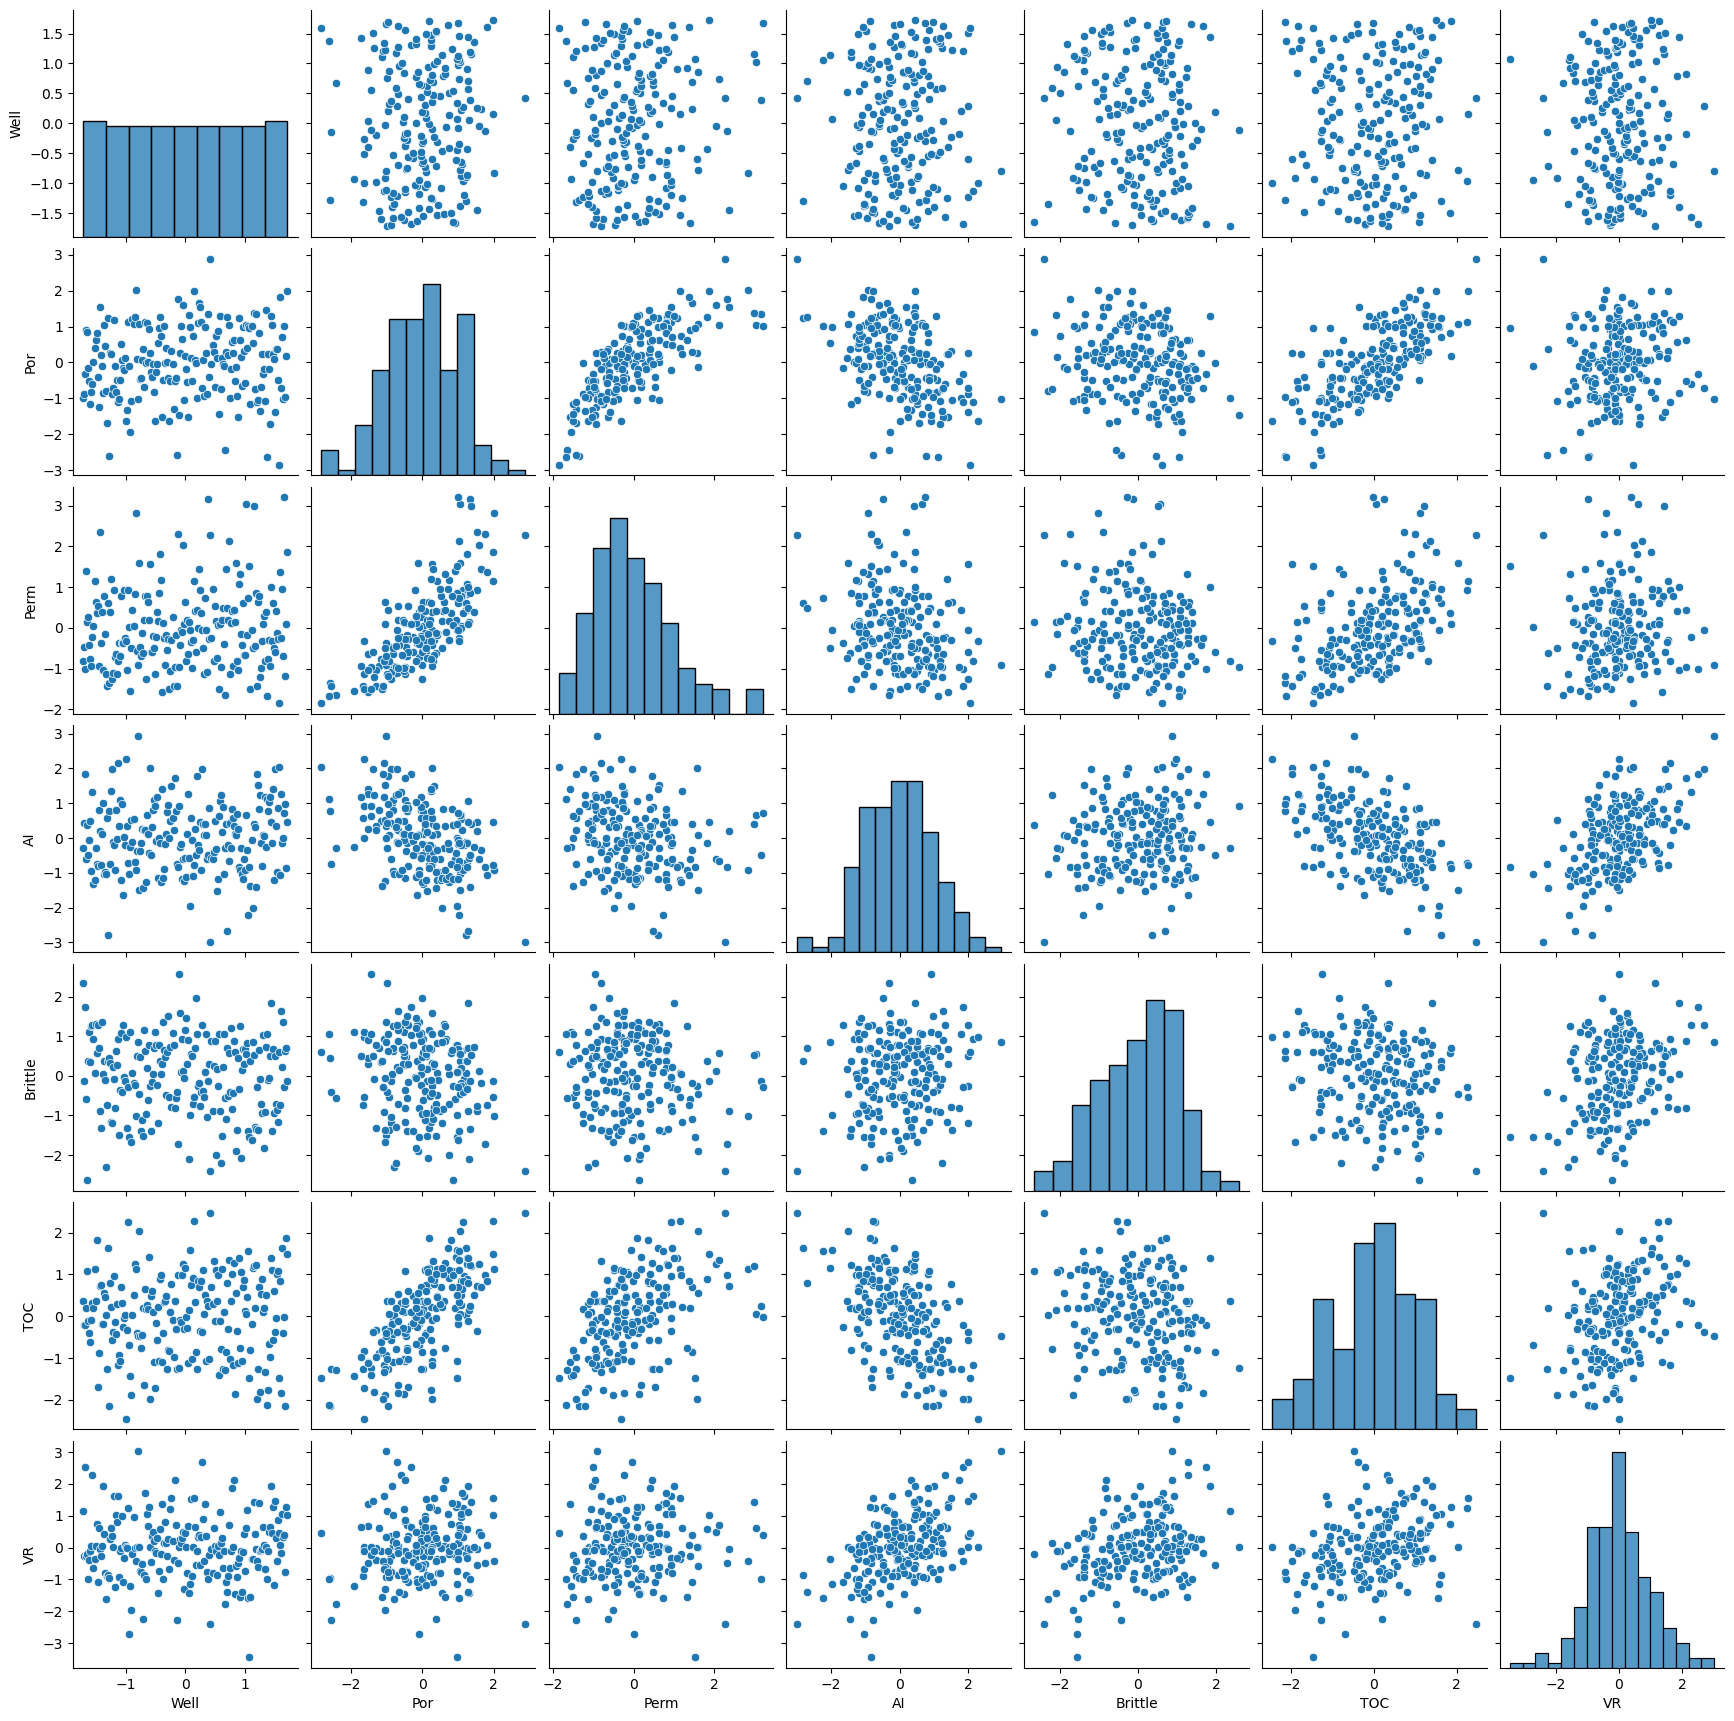

In [73]:
# pairplot
sns.pairplot(X_df)
plt.show()

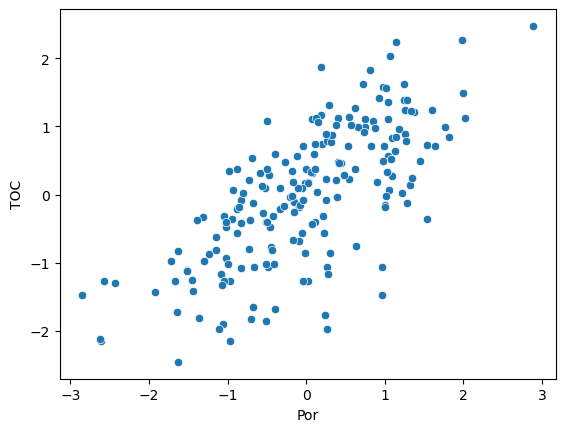

In [74]:
# Plot histogram
sns.scatterplot(data=X_df, x="Por", y="TOC")
# pandas
#X_df.plot.scatter(x='Por', y='TOC')
plt.show()


### 5. Plot in 3D

Text(0.5, 0, 'VR')

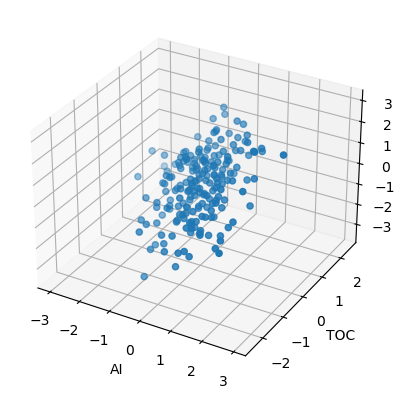

In [76]:
plot3d = plt.axes (projection='3d')
x = X_df['AI'].values
y = X_df['TOC'].values
z = X_df['VR'].values
plot3d.scatter3D (x, y, z)
plot3d.set_xlabel ('AI')
plot3d.set_ylabel ('TOC')
plot3d.set_zlabel ('VR')

* Unfortunately, it's not possible to show all features in one plot.
* Compress them all into 3 features (or 2) then plot them
* Compressing by dimensionality reduction

### 6. Dimensionality reduction
#### Using Principal Component Analysis (PCA)

In [77]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(X)


PCA()

#### Explained variance

In [78]:
exp_var = pca.explained_variance_ratio_
print(exp_var)


[9.40845685e-01 5.58103016e-02 2.92916721e-03 2.96980592e-04
 7.94190143e-05 3.61747625e-05 2.27170121e-06]


#### Cumulative variance

In [79]:
cumul_var = np.cumsum(exp_var)
cumul_var



array([0.94084569, 0.99665599, 0.99958515, 0.99988213, 0.99996155,
       0.99999773, 1.        ])

#### Ratios of explained variances

In [80]:
exp_var_ratio = pca.explained_variance_ratio_
exp_var_ratio

array([9.40845685e-01, 5.58103016e-02, 2.92916721e-03, 2.96980592e-04,
       7.94190143e-05, 3.61747625e-05, 2.27170121e-06])

### Show the explained variance, cumulatuive abd ratios

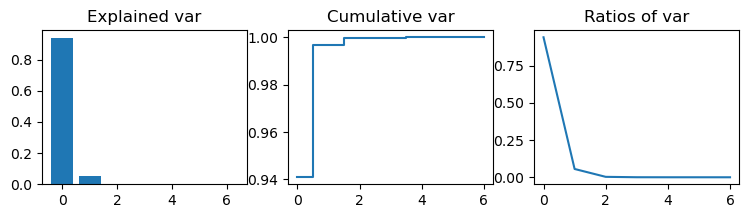

In [81]:
plt.figure(figsize=(9,2))
plt.subplot(1,3,1)
plt.bar(range(0,len(exp_var)), exp_var)
plt.title('Explained var')
plt.subplot(1,3,2)
plt.step(range(0,len(exp_var)), cumul_var, where='mid')
plt.title('Cumulative var')
plt.subplot(1,3,3)
plt.plot(exp_var_ratio)
plt.title('Ratios of var')
plt.show()

### Apply PCA to reduce data dimension

In [82]:
X_reduced = pca.transform(X)
X_reduced.shape

(200, 7)

### Take the three first PCs

In [83]:
# save X_s in a dataframe
X_reduced_df = pd.DataFrame(data=X_reduced[:,:3])
X_reduced_df.columns = ['w1', 'w2', 'w3']
X_reduced_df.head(5)

,w1,w2,w3
0,100.175654,-31.282421,1.189383
1,98.448466,3.895414,2.480468
2,97.992549,-22.661849,0.170817
3,96.291618,10.509428,-3.376272
4,94.703288,39.273650,-0.821061


Text(0.5, 0, 'w3')

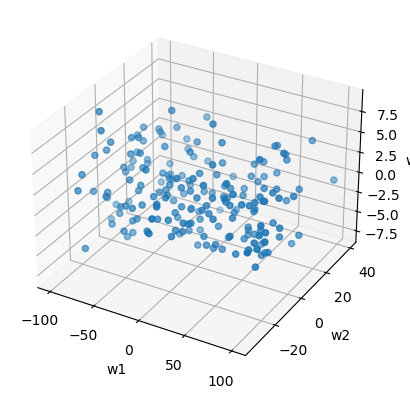

In [84]:
# 3D plot 
plot3d = plt.axes (projection='3d')
x = X_reduced_df['w1'].values
y = X_reduced_df['w2'].values
z = X_reduced_df['w3'].values
plot3d.scatter3D (x, y, z)
plot3d.set_xlabel ('w1')
plot3d.set_ylabel ('w2')
plot3d.set_zlabel ('w3')

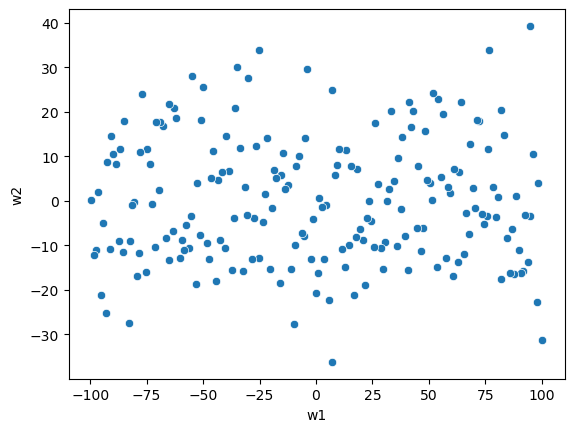

In [85]:
# Plot histogram
sns.scatterplot(data=X_reduced_df, x="w1", y="w2")
# pandas
#X_df.plot.scatter(x='Por', y='TOC')
plt.show()
